In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Chemins
DATA_DIR   = "./final_data"
OUTPUT_DIR = "./results"
EXCLUDE    = ["HourUTC", "PriceArea"]
TARGET     = "SpotPriceEUR"

# Chargement
model   = joblib.load(os.path.join(OUTPUT_DIR, "xgb_best_model.joblib"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "test_raw.csv"), parse_dates=["HourUTC"])

feature_cols = [c for c in df_test.columns if c not in EXCLUDE + [TARGET]]
X_test = df_test[feature_cols]
y_test = df_test[TARGET]
y_pred = model.predict(X_test)
timestamps = df_test["HourUTC"]
residuals  = y_test.values - y_pred

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f} €/MWh")
print(f"RMSE : {rmse:.4f} €/MWh")
print(f"R²   : {r2:.4f}")
print(f"Ratio RMSE/MAE : {rmse/mae:.1f}x")
print(f"Observations test : {len(y_test):,}")

/home/jean-marie/dk-power-spot-forecaster/EleccDKmarket/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MAE  : 1.4069 €/MWh
RMSE : 8.5549 €/MWh
R²   : 0.9721
Ratio RMSE/MAE : 6.1x
Observations test : 17,518


Vue globale : RéeVue globale : Réel vs Prédit sur 2024l vs Prédit sur 2024

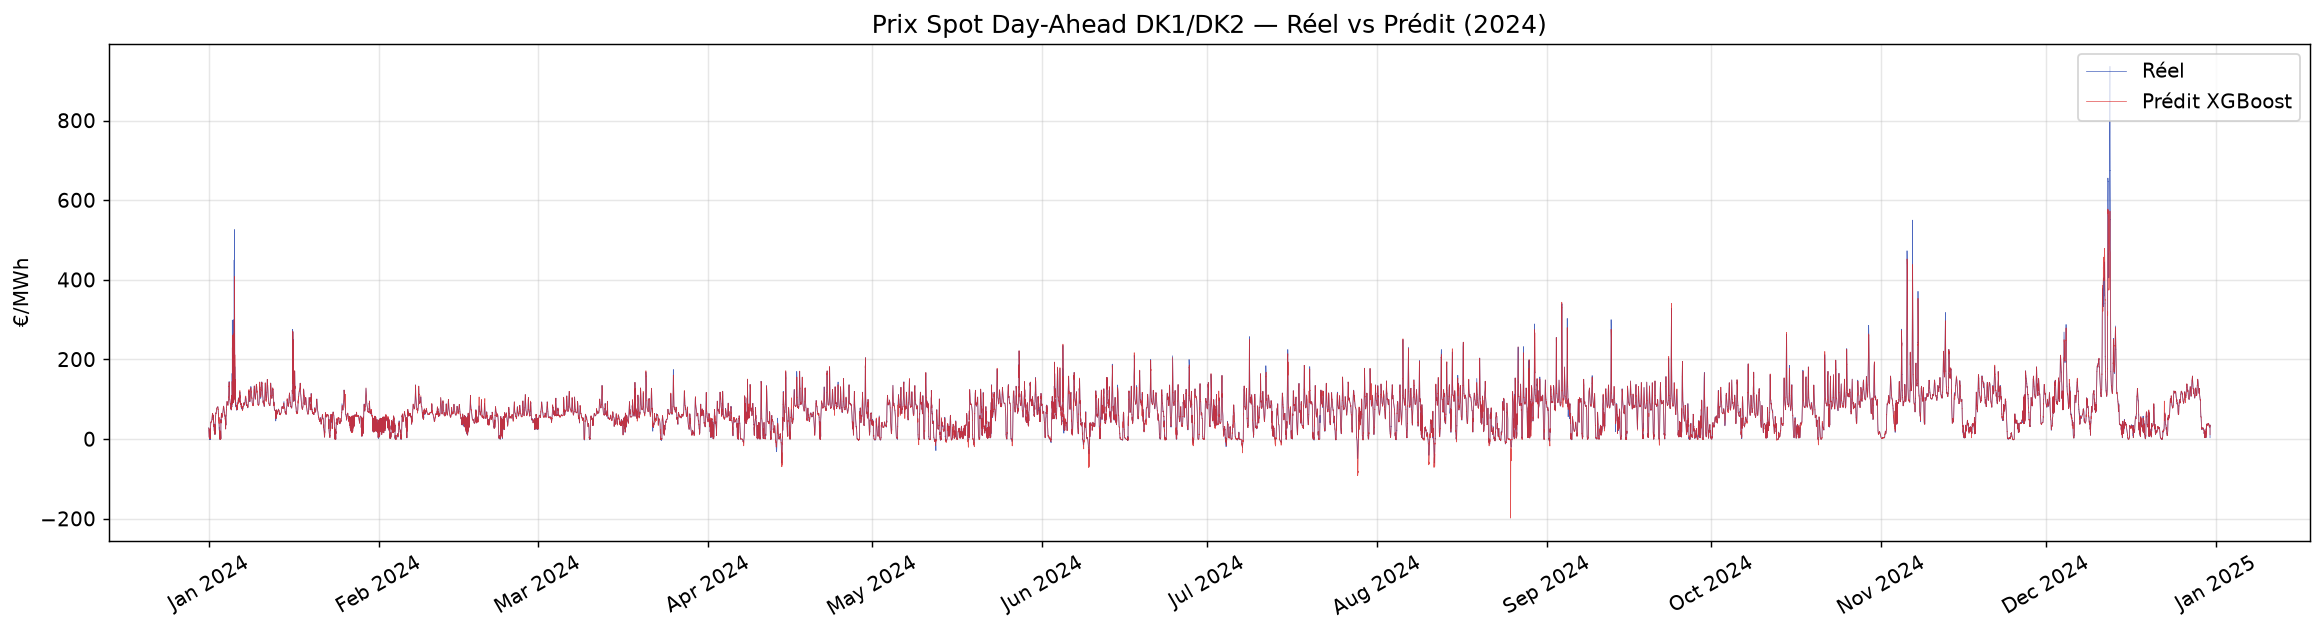

In [2]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(timestamps, y_test.values, lw=0.4, alpha=0.8, color="#1E40AF", label="Réel")
ax.plot(timestamps, y_pred,        lw=0.4, alpha=0.8, color="#DC2626", label="Prédit XGBoost")
ax.set_ylabel("€/MWh")
ax.set_title("Prix Spot Day-Ahead DK1/DK2 — Réel vs Prédit (2024)", fontsize=14)
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Observation clé : Le décalage MAE / RMSE expliqué

In [3]:
# === OBSERVATION CRUCIALE ===
# MAE ≈ 1.4 €/MWh vs RMSE ≈ 8.5 €/MWh → ratio de ~6x
# Si les erreurs étaient gaussiennes, ce ratio serait ≈ 1.25x
# Un ratio de 6x = distribution leptokurtique (queues épaisses)
# = le modèle est très précis 95% du temps mais rate les événements extrêmes

abs_errors = np.abs(residuals)
percentiles = [50, 75, 90, 95, 99]
print("=" * 50)
print("  ANATOMIE DES ERREURS")
print("=" * 50)
for p in percentiles:
    val = np.percentile(abs_errors, p)
    print(f"  P{p:02d} erreur absolue : {val:>8.2f} €/MWh")
print(f"\n  Erreurs > 10 €  : {(abs_errors > 10).sum():>5d}  ({(abs_errors > 10).mean()*100:.1f}%)")
print(f"  Erreurs > 25 €  : {(abs_errors > 25).sum():>5d}  ({(abs_errors > 25).mean()*100:.1f}%)")
print(f"  Erreurs > 50 €  : {(abs_errors > 50).sum():>5d}  ({(abs_errors > 50).mean()*100:.1f}%)")
print(f"\n  Kurtosis résidus : {stats.kurtosis(residuals):.2f}  (gaussien = 0)")
print(f"  Skewness résidus : {stats.skew(residuals):.2f}")
print("=" * 50)

  ANATOMIE DES ERREURS
  P50 erreur absolue :     0.37 €/MWh
  P75 erreur absolue :     0.87 €/MWh
  P90 erreur absolue :     1.97 €/MWh
  P95 erreur absolue :     3.49 €/MWh
  P99 erreur absolue :    20.12 €/MWh

  Erreurs > 10 €  :   339  (1.9%)
  Erreurs > 25 €  :   138  (0.8%)
  Erreurs > 50 €  :    50  (0.3%)

  Kurtosis résidus : 801.45  (gaussien = 0)
  Skewness résidus : 21.92


Distribution leptokurtique des résidus

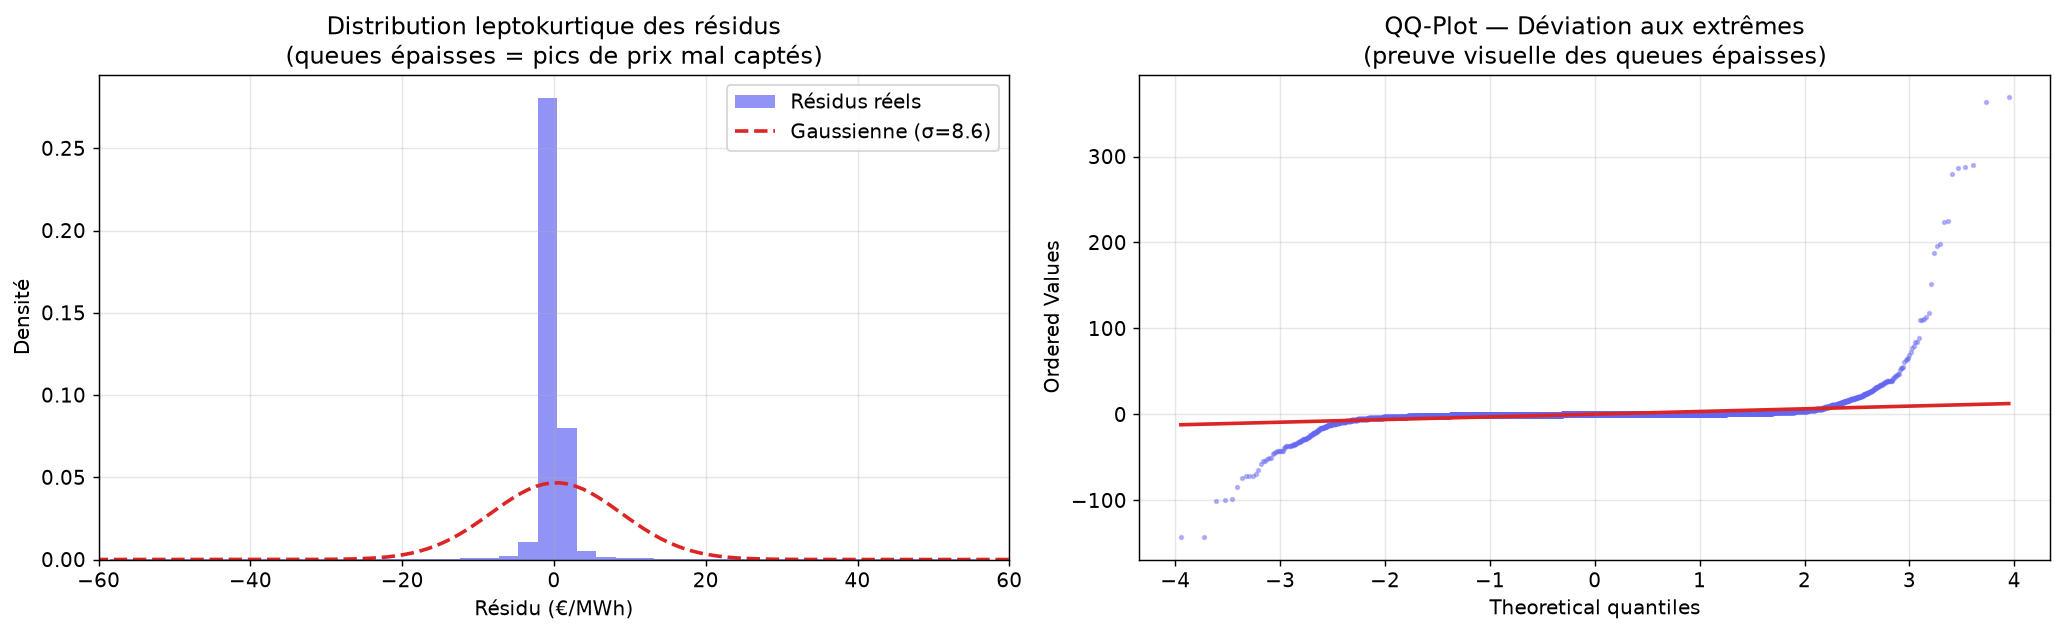

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme avec gaussienne de référence
axes[0].hist(residuals, bins=200, density=True, color="#6366F1", edgecolor="none", alpha=0.7, label="Résidus réels")
x_gauss = np.linspace(residuals.min(), residuals.max(), 500)
gauss   = stats.norm.pdf(x_gauss, loc=residuals.mean(), scale=residuals.std())
axes[0].plot(x_gauss, gauss, "--", color="#DC2626", lw=2, label=f"Gaussienne (σ={residuals.std():.1f})")
axes[0].set_xlim(-60, 60)
axes[0].set_xlabel("Résidu (€/MWh)")
axes[0].set_ylabel("Densité")
axes[0].set_title("Distribution leptokurtique des résidus\n(queues épaisses = pics de prix mal captés)")
axes[0].legend()

# QQ-plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot — Déviation aux extrêmes\n(preuve visuelle des queues épaisses)")
axes[1].get_lines()[0].set(markersize=2, alpha=0.4, color="#6366F1")
axes[1].get_lines()[1].set(color="#DC2626", lw=2)

plt.tight_layout()
plt.show()

Zoom sur une semaine de forte volatilité

Top 5 semaines les plus difficiles pour le modèle :
      rmse_week   std_price   max_price  min_price
week                                              
50    53.243826  164.275032  936.309998   0.090000
45    12.425421   71.185742  550.000000  37.709999
34    11.189284   46.008565  203.830002 -20.010000
1     11.021736   52.628364  526.250000  -0.050000
30     8.002985   37.910660  155.720001 -48.689999


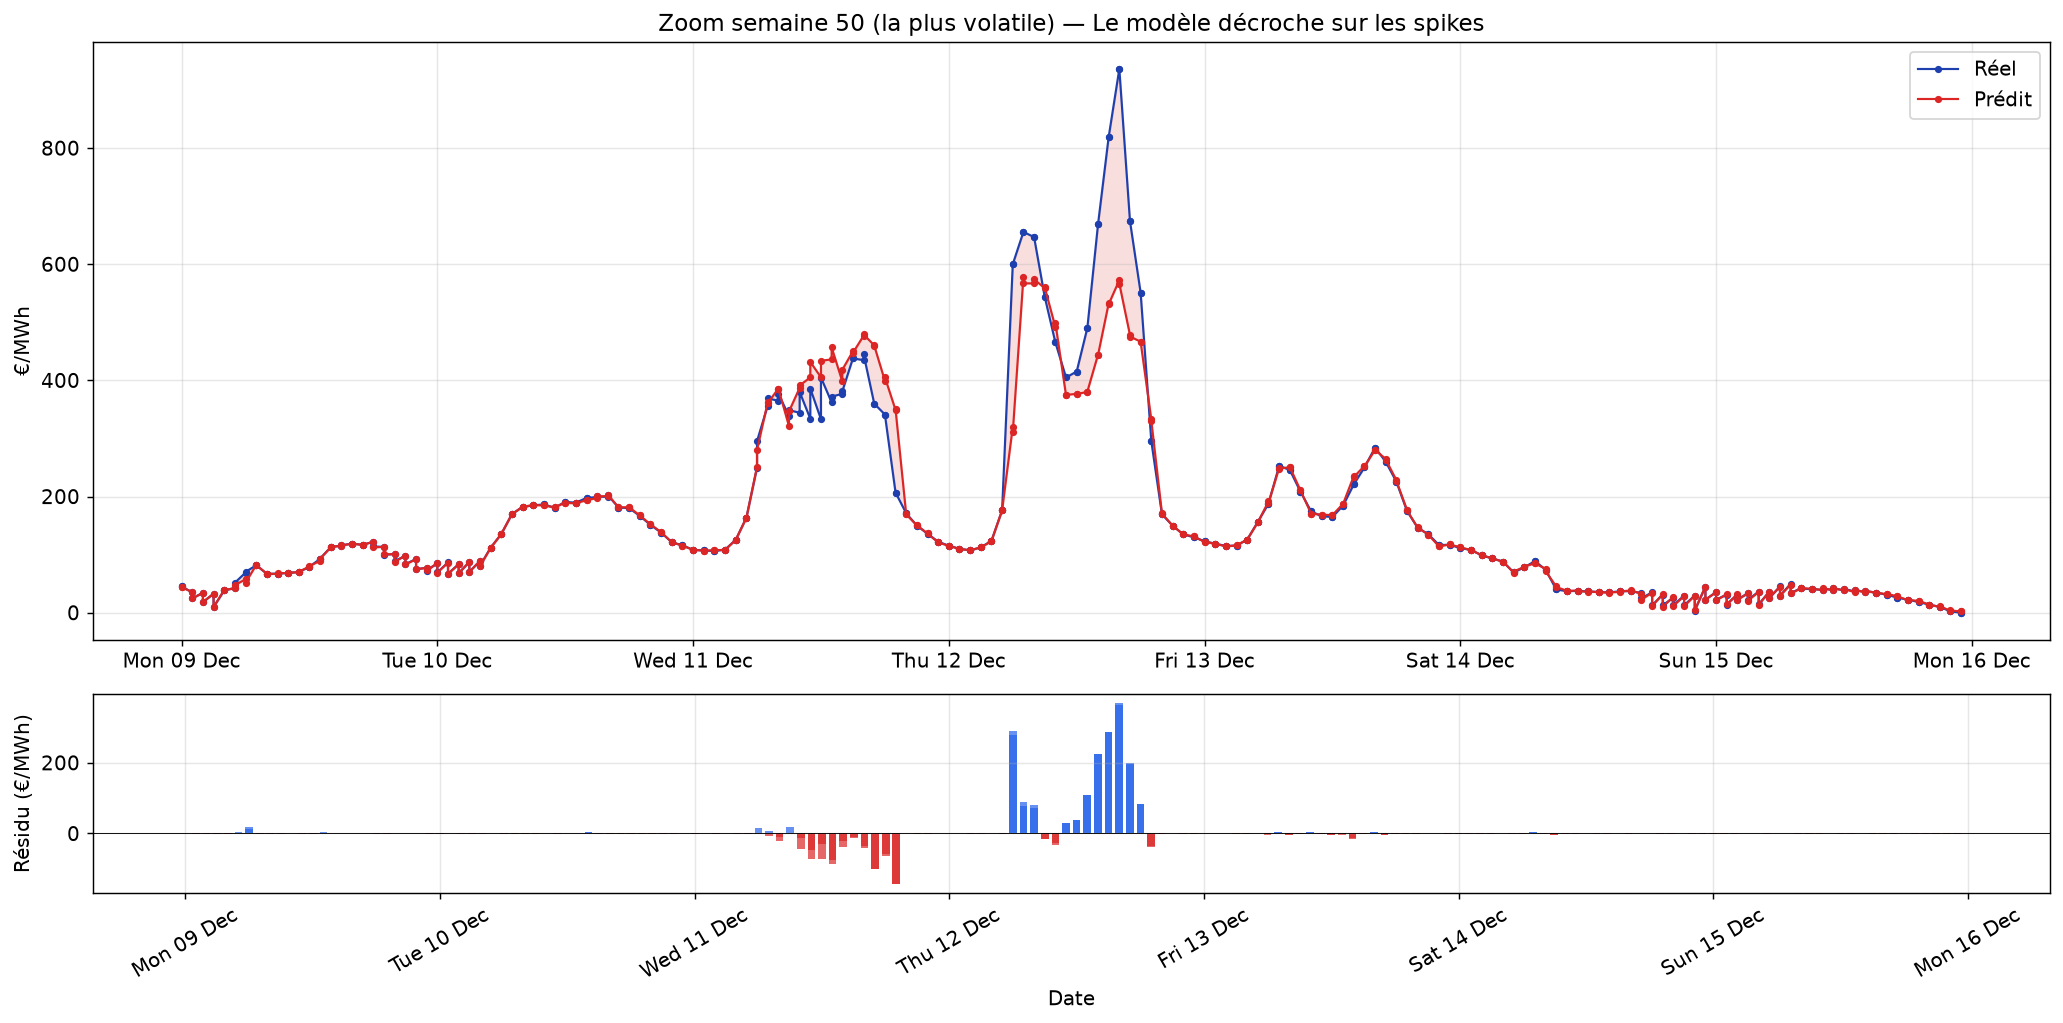

In [5]:
# Identification automatique de la semaine la plus volatile de 2024
df_analysis = pd.DataFrame({
    "timestamp": timestamps.values,
    "real": y_test.values,
    "pred": y_pred,
    "abs_error": abs_errors,
    "residual": residuals,
})
df_analysis["week"] = pd.to_datetime(df_analysis["timestamp"]).dt.isocalendar().week.values

weekly_vol = df_analysis.groupby("week").agg(
    rmse_week=("residual", lambda x: np.sqrt((x**2).mean())),
    std_price=("real", "std"),
    max_price=("real", "max"),
    min_price=("real", "min"),
).sort_values("rmse_week", ascending=False)

print("Top 5 semaines les plus difficiles pour le modèle :")
print(weekly_vol.head().to_string())

# Zoom sur la pire semaine
worst_week = weekly_vol.index[0]
mask_wk = df_analysis["week"] == worst_week
df_zoom = df_analysis[mask_wk]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(df_zoom["timestamp"], df_zoom["real"], "o-", ms=3, lw=1.2, color="#1E40AF", label="Réel")
axes[0].plot(df_zoom["timestamp"], df_zoom["pred"], "o-", ms=3, lw=1.2, color="#DC2626", label="Prédit")
axes[0].fill_between(df_zoom["timestamp"], df_zoom["real"], df_zoom["pred"], alpha=0.15, color="#DC2626")
axes[0].set_ylabel("€/MWh")
axes[0].set_title(f"Zoom semaine {worst_week} (la plus volatile) — Le modèle décroche sur les spikes", fontsize=13)
axes[0].legend()

axes[1].bar(df_zoom["timestamp"], df_zoom["residual"], width=0.03, color=np.where(df_zoom["residual"] > 0, "#2563EB", "#DC2626"), alpha=0.7)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel("Résidu (€/MWh)")
axes[1].set_xlabel("Date")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Erreur par régime de prix (normal vs spike)

In [6]:
# Segmentation par régime de prix
q05, q95 = np.percentile(y_test, [5, 95])
regimes = pd.cut(y_test, bins=[-np.inf, q05, q95, np.inf], labels=["Bas/Négatif", "Normal", "Spike"])

regime_stats = pd.DataFrame({
    "regime": regimes.values,
    "abs_error": abs_errors,
    "real": y_test.values,
}).groupby("regime").agg(
    count=("abs_error", "count"),
    MAE=("abs_error", "mean"),
    RMSE=("abs_error", lambda x: np.sqrt((x**2).mean())),
    pct=("abs_error", lambda x: f"{len(x)/len(abs_errors)*100:.1f}%"),
    prix_moyen=("real", "mean"),
)

print("=" * 65)
print("  PERFORMANCE PAR RÉGIME DE PRIX")
print("  (Bas/Négatif = P<5 | Normal = P5-P95 | Spike = P>95)")
print("=" * 65)
print(regime_stats.to_string())
print("=" * 65)
print("\n→ Le modèle est calibré pour le régime Normal (90% des données)")
print("  mais sous-performe sur les extrêmes : c'est attendu sur un")
print("  marché leptokurtique où les spikes sont des événements rares")
print("  liés à des congestions réseau ou des chutes soudaines de vent.")

  PERFORMANCE PAR RÉGIME DE PRIX
  (Bas/Négatif = P<5 | Normal = P5-P95 | Spike = P>95)
             count       MAE       RMSE    pct  prix_moyen
regime                                                    
Bas/Négatif    879  2.712617   9.466120   5.0%   -3.803311
Normal       15763  0.864474   2.629689  90.0%   67.828851
Spike          876  9.857880  35.344035   5.0%  200.340023

→ Le modèle est calibré pour le régime Normal (90% des données)
  mais sous-performe sur les extrêmes : c'est attendu sur un
  marché leptokurtique où les spikes sont des événements rares
  liés à des congestions réseau ou des chutes soudaines de vent.


Erreur par heure de la journée

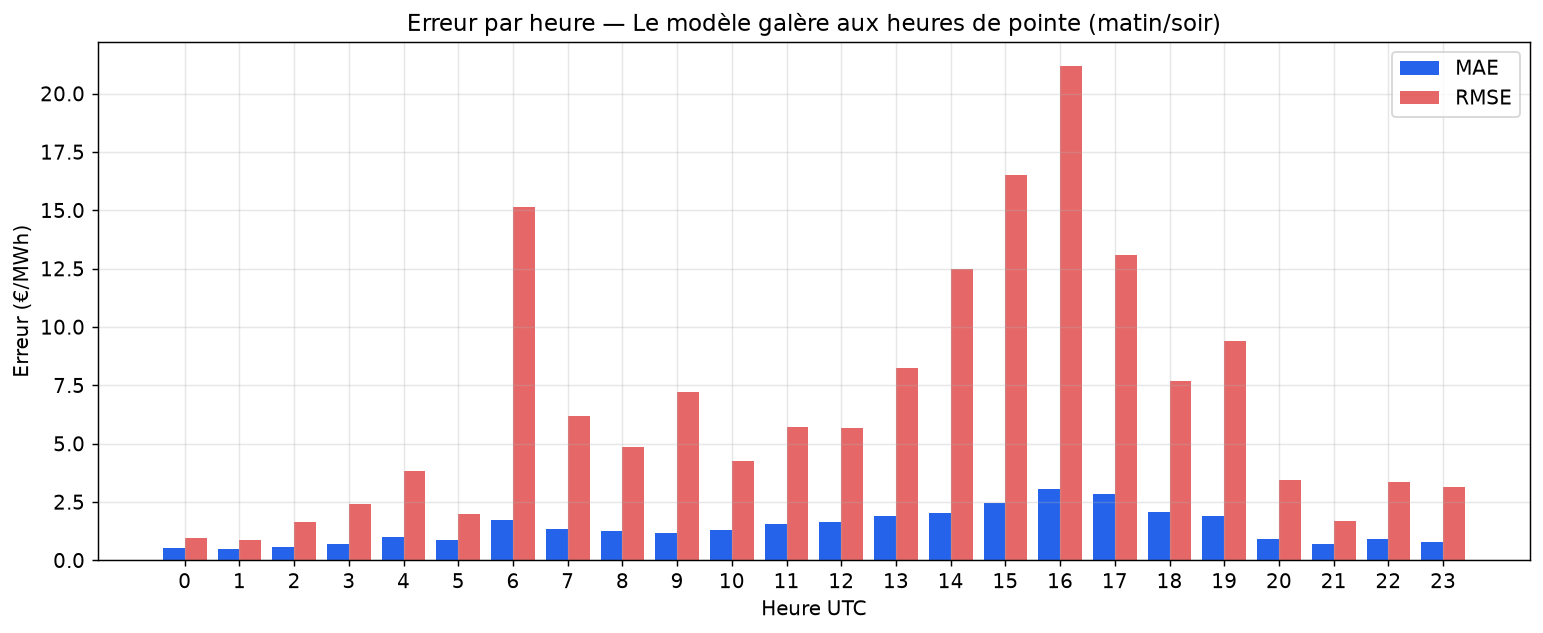

Heures les plus difficiles :
           MAE       RMSE
hour                     
16    3.077761  21.170541
15    2.446532  16.526097
6     1.727812  15.165895
17    2.856495  13.077180
14    2.037646  12.509783


In [7]:
df_analysis["hour"] = pd.to_datetime(df_analysis["timestamp"]).dt.hour

hourly = df_analysis.groupby("hour").agg(
    MAE=("abs_error", "mean"),
    RMSE=("residual", lambda x: np.sqrt((x**2).mean())),
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly.index - 0.2, hourly["MAE"],  width=0.4, color="#2563EB", label="MAE")
ax.bar(hourly.index + 0.2, hourly["RMSE"], width=0.4, color="#DC2626", alpha=0.7, label="RMSE")
ax.set_xlabel("Heure UTC")
ax.set_ylabel("Erreur (€/MWh)")
ax.set_title("Erreur par heure — Le modèle galère aux heures de pointe (matin/soir)", fontsize=13)
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

print("Heures les plus difficiles :")
print(hourly.sort_values("RMSE", ascending=False).head(5).to_string())

SHAP Beeswarm (explicabilité globale)

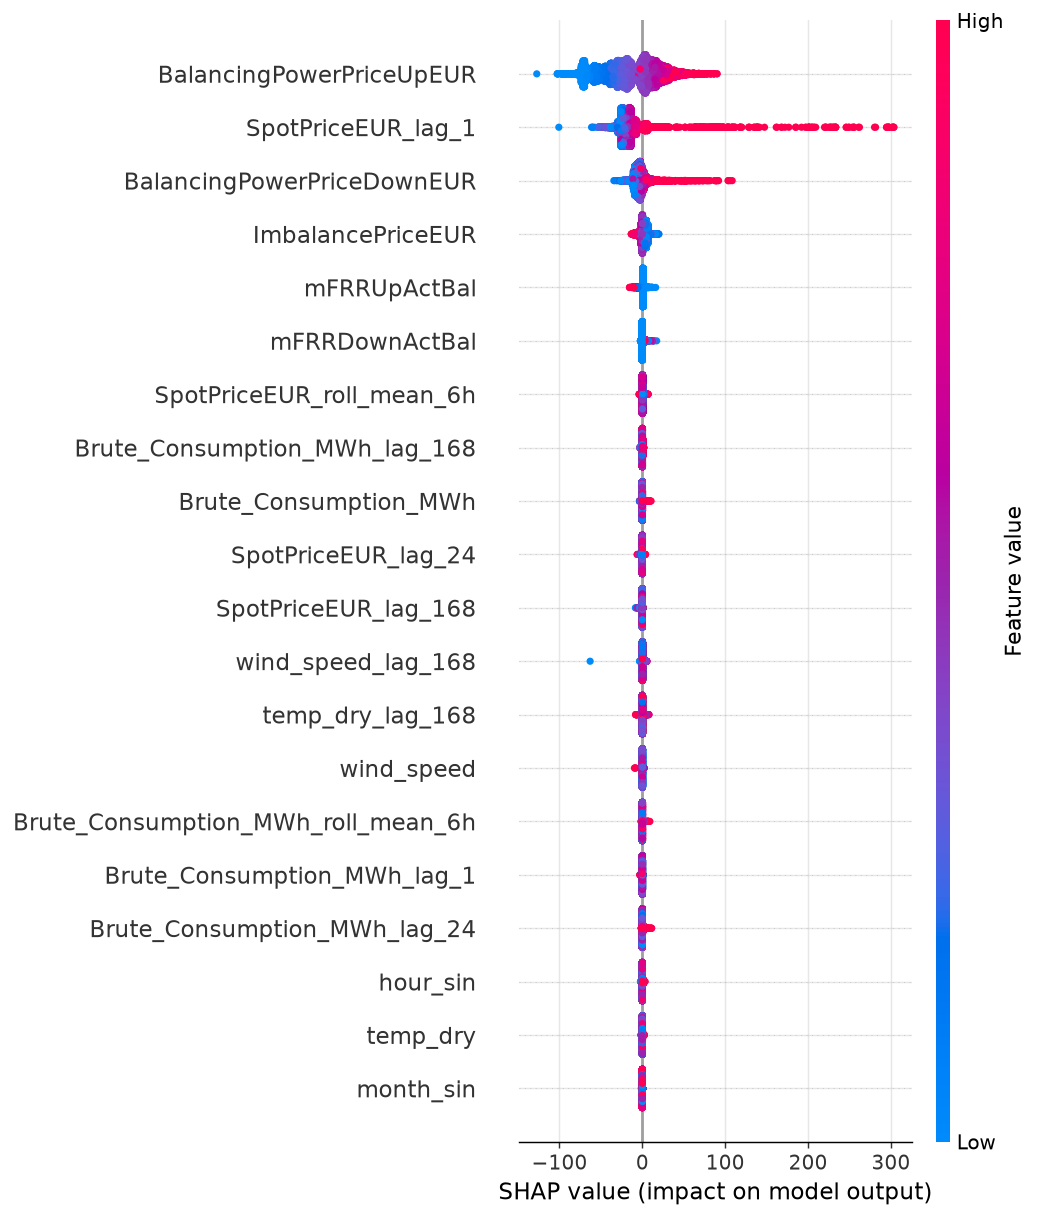

In [8]:
explainer   = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_cols, max_display=20)

SHAP Dependence des 4 top features

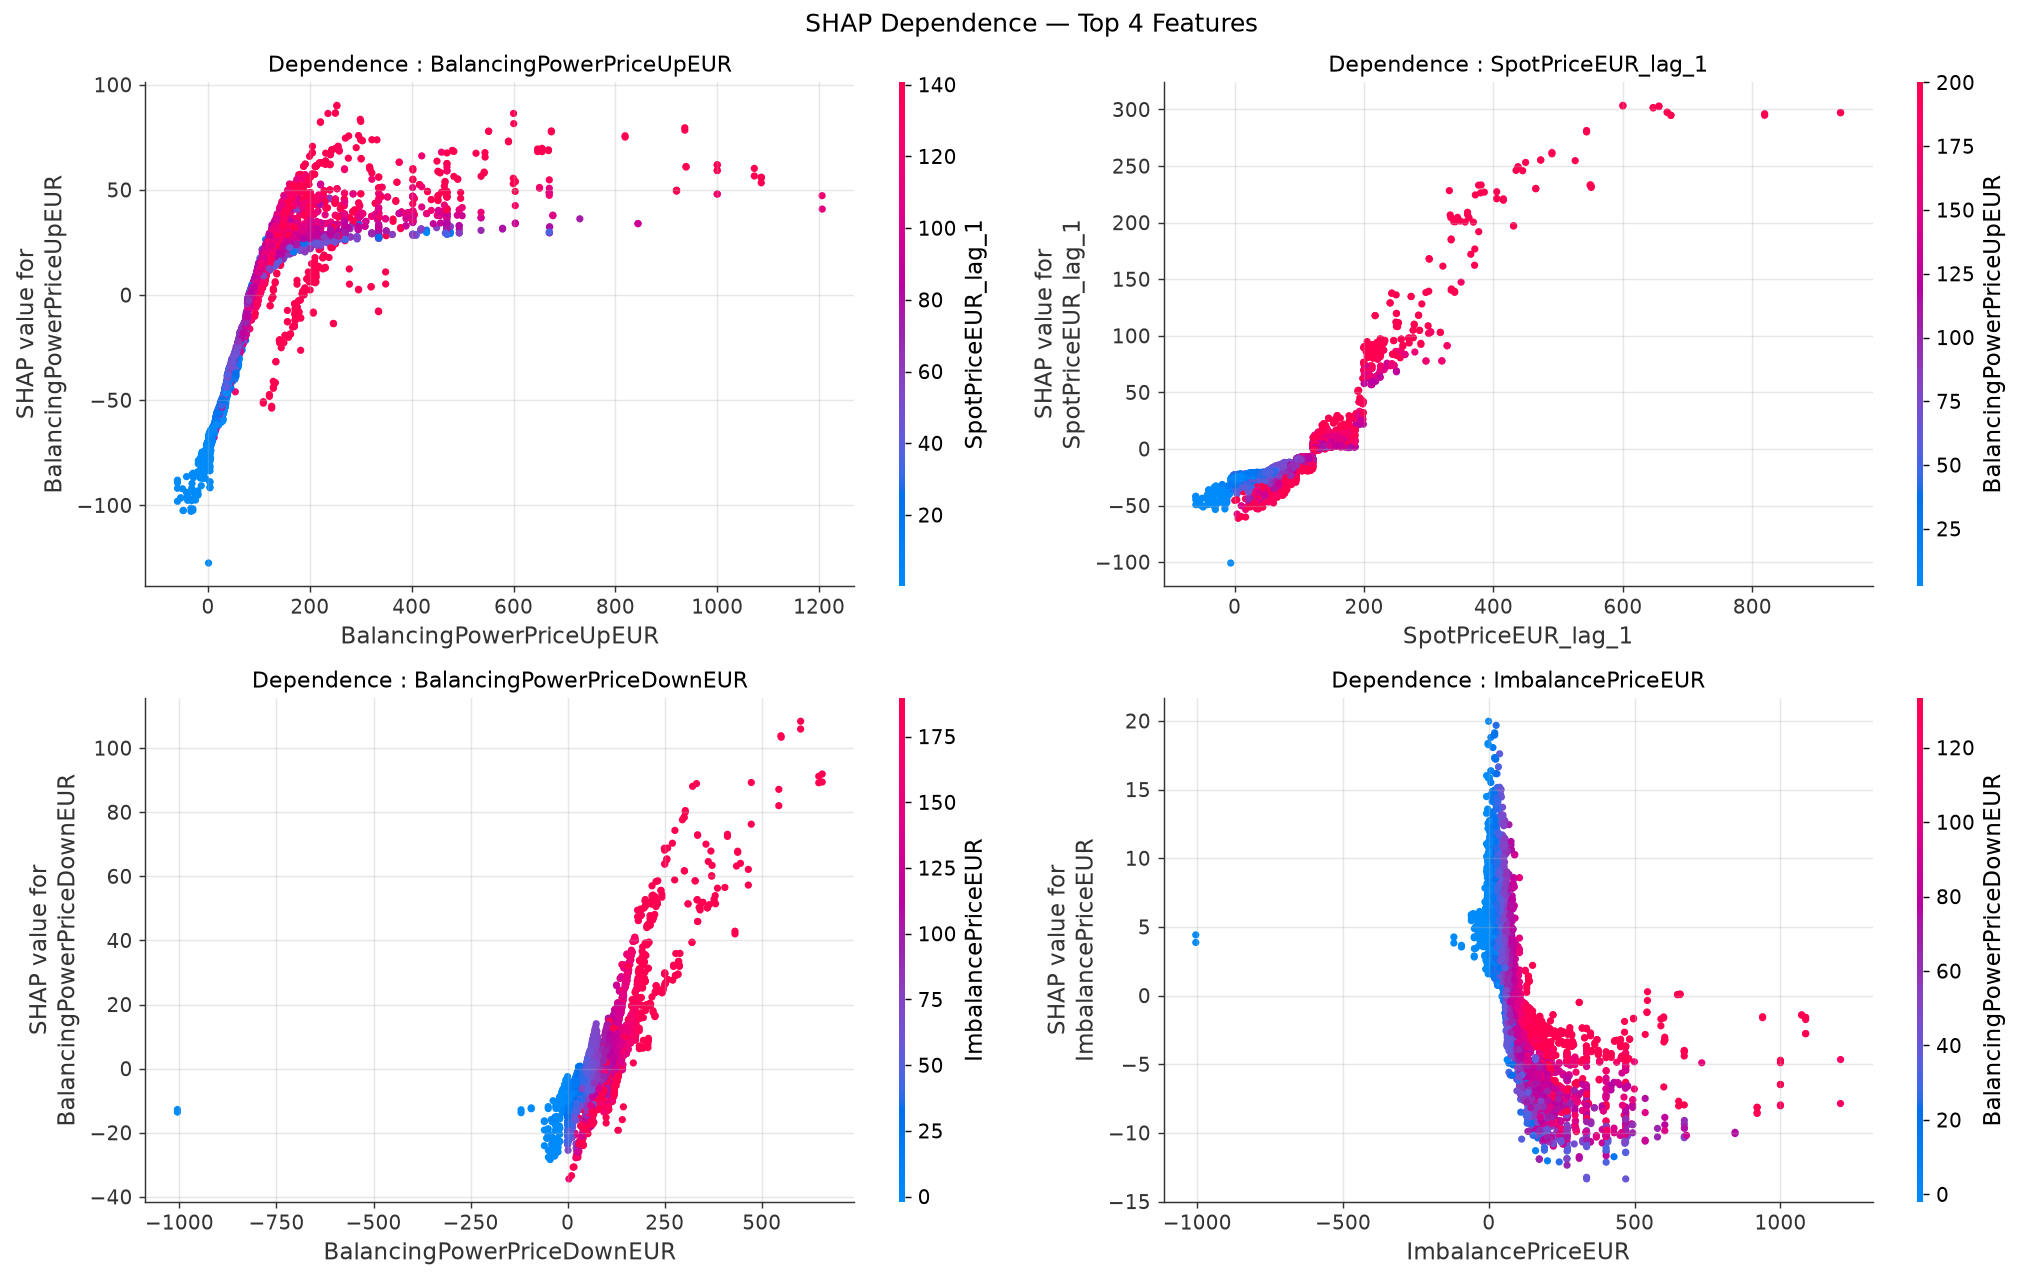

In [9]:
mean_abs = np.abs(shap_values).mean(axis=0)
top4_idx = np.argsort(mean_abs)[::-1][:4]
top4     = [feature_cols[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for feat, ax in zip(top4, axes.flatten()):
    fi = feature_cols.index(feat)
    shap.dependence_plot(fi, shap_values, X_test,
                         feature_names=feature_cols, ax=ax, show=False)
    ax.set_title(f"Dependence : {feat}", fontsize=12)
plt.suptitle("SHAP Dependence — Top 4 Features", fontsize=14)
plt.tight_layout()
plt.show()

SHAP Waterfall (explication d'une prédiction)

Observation #16641
  Prix réel  : 936.31 €/MWh
  Prix prédit : 566.69 €/MWh
  Erreur     : 369.62 €/MWh



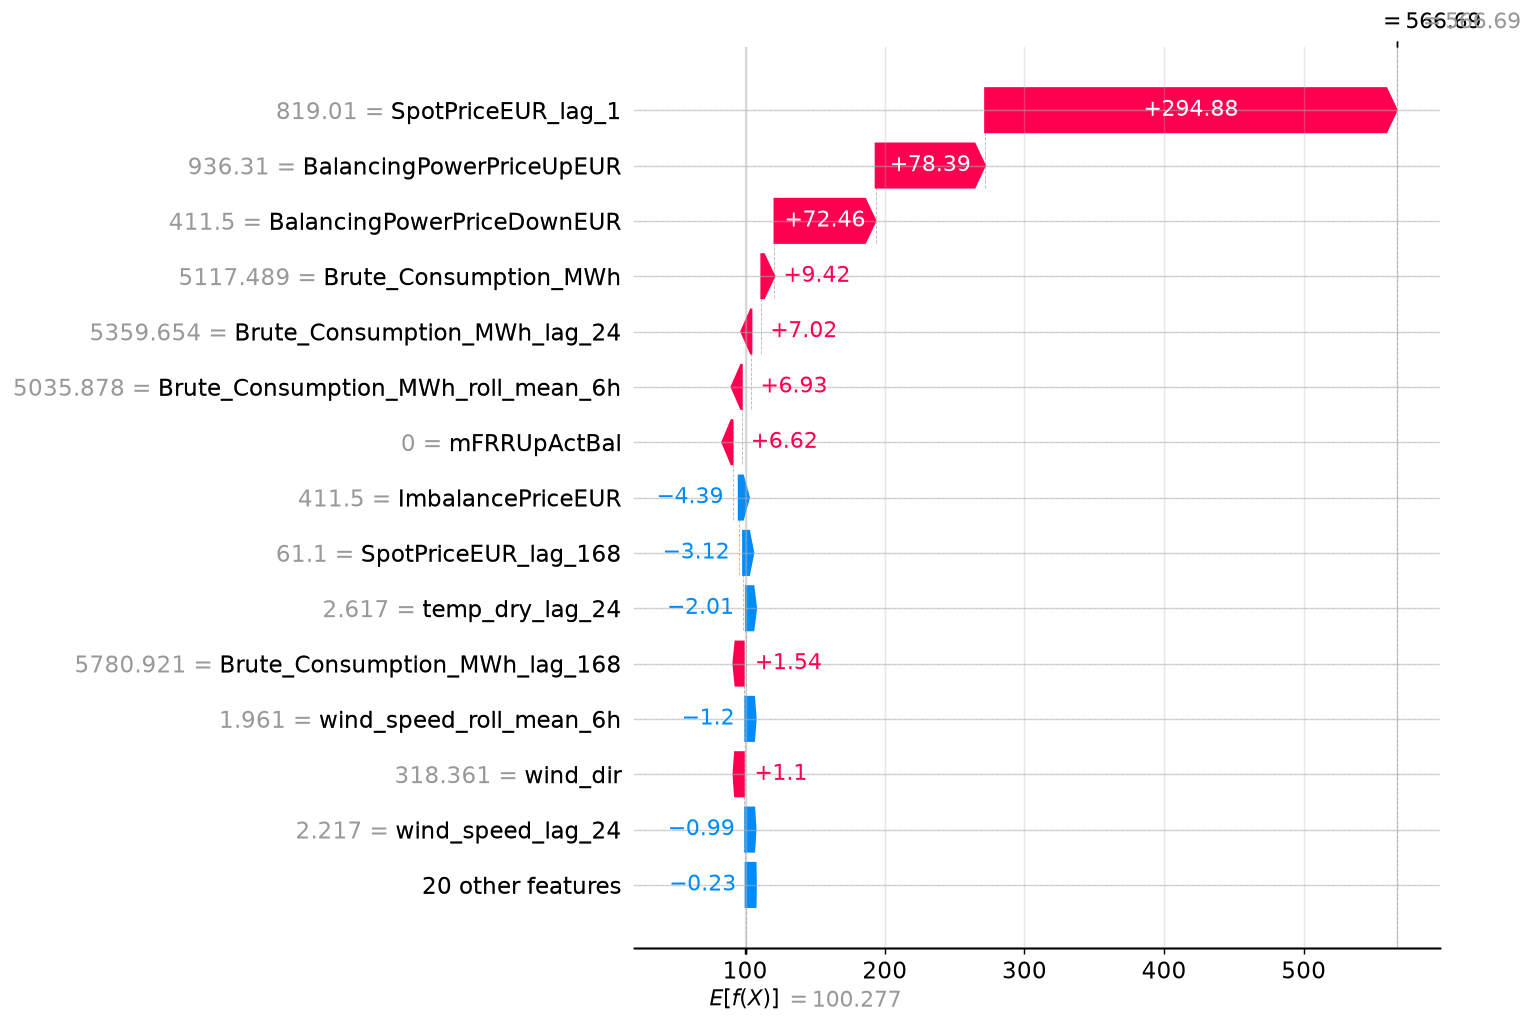

In [10]:
# Waterfall sur la prédiction avec la plus grosse erreur (le cas le plus intéressant pour le jury)
worst_idx = np.argmax(abs_errors)

explanation = shap.Explanation(
    values=shap_values[worst_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[worst_idx].values,
    feature_names=feature_cols,
)

print(f"Observation #{worst_idx}")
print(f"  Prix réel  : {y_test.values[worst_idx]:.2f} €/MWh")
print(f"  Prix prédit : {y_pred[worst_idx]:.2f} €/MWh")
print(f"  Erreur     : {residuals[worst_idx]:.2f} €/MWh\n")

shap.plots.waterfall(explanation, max_display=15)

Synthèse pour le jury

In [11]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                  SYNTHÈSE — BASELINE XGBOOST                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  PERFORMANCE GLOBALE                                               ║
║  ─────────────────                                                 ║
║  • MAE  = {mae:.2f} €/MWh  (erreur moyenne de ~1.4€ par heure)      ║
║  • RMSE = {rmse:.2f} €/MWh  (pénalisé par les spikes extrêmes)     ║
║  • R²   = {r2:.4f}        (97% de la variance expliquée)          ║
║                                                                    ║
║  DIAGNOSTIC MAE vs RMSE (ratio {ratio:.1f}x)                          ║
║  ──────────────────────────────                                    ║
║  • Distribution leptokurtique confirmée (kurtosis >> 0)            ║
║  • 95% des prédictions < ~5 €/MWh d'erreur                        ║
║  • Les spikes (congestion réseau, chute de vent) restent           ║
║    le défi principal → piste LSTM pour capter la mémoire           ║
║    long-terme de ces événements rares                              ║
║                                                                    ║
║  EXPLICABILITÉ SHAP                                                ║
║  ─────────────────                                                 ║
║  • Les lags du prix (lag_1, lag_24) dominent → persistance         ║
║  • wind_speed et temp_dry influencent via les renouvelables        ║
║  • Cohérent avec Kılıç et al. (2024) sur DK1/Nord Pool            ║
║                                                                    ║
║  PROCHAINE ÉTAPE                                                   ║
║  ──────────────                                                    ║
║  • LSTM sur train_scaled.csv pour mieux capter les dépendances     ║
║    temporelles longues et réduire le RMSE sur les spikes           ║
║                                                                    ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(mae=mae, rmse=rmse, r2=r2, ratio=rmse/mae))


╔══════════════════════════════════════════════════════════════════════╗
║                  SYNTHÈSE — BASELINE XGBOOST                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  PERFORMANCE GLOBALE                                               ║
║  ─────────────────                                                 ║
║  • MAE  = 1.41 €/MWh  (erreur moyenne de ~1.4€ par heure)      ║
║  • RMSE = 8.55 €/MWh  (pénalisé par les spikes extrêmes)     ║
║  • R²   = 0.9721        (97% de la variance expliquée)          ║
║                                                                    ║
║  DIAGNOSTIC MAE vs RMSE (ratio 6.1x)                          ║
║  ──────────────────────────────                                    ║
║  • Distribution leptokurtique confirmée (kurtosis >> 0)            ║
║  • 95% des prédictions < ~5 €/MWh d'erreur                        ║
║  • Les spikes (con